In [73]:
from astropy.table import Table
from astropy.io import fits

from scipy.optimize import curve_fit, minimize

import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

### read in data

In [2]:
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/'
NSA_FN = DATA_FOLDER + 'nsa_v1_0_1.fits'
# KIAS_FN = DATA_FOLDER + 'NSA_v1_0_1_vflag_Portsmouth.fits'

In [3]:
NSA = Table.read(NSA_FN)
NSA[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.915525,293.50247 .. 1094.6666,-0.010805 .. 0.009306902,3.9630737e-05 .. 2.6251464e-06,6833158000.0,0.00017553588 .. 1.14686,0.004447123,0.09061434,0.025269886,0.0
J094630.85-004554.5,09h/m00/J094630.85-004554.5,146.6285851269414,-0.7651620976591762,1,-1,-1,-1,-1,-1,17.318521,0.06465632,sdss,0.06491773,1239,2,175,301,735.56384,1277.3636,1,0.06403577,2.4606192 .. 443.66675,5.447516 .. 0.006137319,1,2.6590455 .. 454.05856,-14.978118 .. -20.68

### magnitude conversion

In [32]:
b_dict = {'u': 1.4e-10,
          'g': 0.9e-10,
          'r': 1.2e-10,
          'i': 1.8e-10,
          'z':7.4e-10,}
def asinh_mag_from_flux(flux, sdss_filter):
    '''

    f given in mgy
    
    '''

    b = b_dict[sdss_filter]

    m = -2.5/np.log(10) * (np.arcsinh(flux/(2*b)) + np.log(b))

    return m

def pogson_mag_from_flux(flux):
    '''

    f given in nmgy
    
    '''


    m = 22.5 -2.5*np.log10(flux)

    return m

### test galaxy

In [148]:
NSA['IAUNAME'][40094]

'J010027.92+155325.8'

In [11]:
iau = NSA[NSA['NSAID'] == 40094]['IAUNAME']
iau

J030526.94+005144.9


In [35]:
NSA[40094]['ELPETRO_FLUX']

masked_array(data=[0.0, 0.0, 11.523157119750977, 60.77724838256836,
                   151.9168701171875, 226.84347534179688,
                   306.69378662109375],
             mask=[False, False, False, False, False, False, False],
       fill_value=nan,
            dtype='>f4')

In [36]:
NSA[40094]['ELPETRO_NMGY']

masked_array(data=[0.0, 0.0, 16.137537002563477, 75.15650939941406,
                   177.0015411376953, 249.96920776367188,
                   322.50616455078125],
             mask=[False, False, False, False, False, False, False],
       fill_value=nan,
            dtype='>f4')

In [37]:
NSA[40094]['ELPETRO_ABSMAG']

masked_array(data=[-14.795866012573242, -16.570842742919922,
                   -18.972810745239258, -20.533958435058594,
                   -21.280698776245117, -21.55124855041504,
                   -21.827777862548828],
             mask=[False, False, False, False, False, False, False],
       fill_value=nan,
            dtype='>f4')

In [43]:
NSA['ELPETRO_THETA_R'][40094]

6.0252204

In [240]:
np.where(NSA['IAUNAME'] == 'J030526.94+005144.9')

(array([37630]),)

In [13]:
icog = Table.read(DATA_FOLDER + 'nsa/cog/' + 'J030526.94+005144.9'
 + '-8-i-cog.fits')
gcog = Table.read(DATA_FOLDER + 'nsa/cog/' + 'J030526.94+005144.9' + '-8-g-cog.fits')
petro = Table.read(DATA_FOLDER + 'nsa/petro/' + 'J030526.94+005144.9' + '-8-petro.fits')

### plot curve of growth

Text(0, 0.5, 'flux [nanomaggies]')

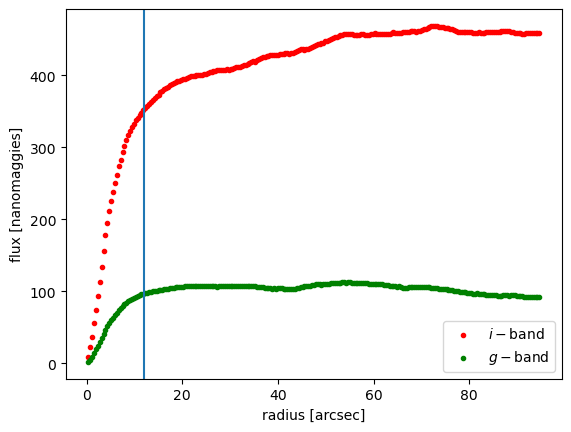

In [44]:
plt.scatter(icog['rbins']*icog['pixscale'], icog['fbins'], marker='.', label='$i-$band', color='r')
plt.scatter(gcog['rbins']*gcog['pixscale'], gcog['fbins'], marker='.', label='$g-$band', color='g')
plt.legend()
plt.axvline(2*NSA['ELPETRO_THETA_R'][40094])
plt.xlabel('radius [arcsec]')
plt.ylabel('flux [nanomaggies]')

In [26]:
i_mag_cog = mag_from_flux(icog['fbins']*10**-9, 'i')
g_mag_cog = mag_from_flux(gcog['fbins']*10**-9, 'g')

Text(0, 0.5, 'flux [asinh magnitudes]')

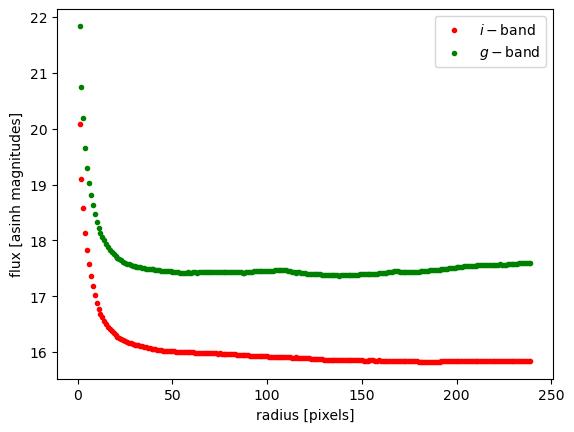

In [27]:
plt.scatter(icog['rbins'], i_mag_cog, marker='.', label='$i-$band', color='r')
plt.scatter(gcog['rbins'], g_mag_cog, marker='.', label='$g-$band', color='g')
plt.legend()
plt.xlabel('radius [pixels]')
plt.ylabel('flux [asinh magnitudes]')

Text(0, 0.5, 'flux [pogson magnitudes]')

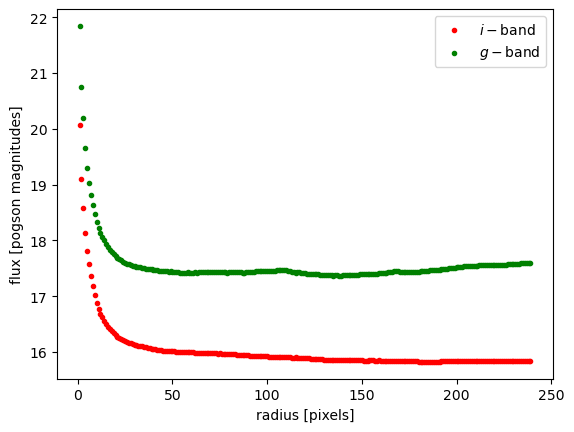

In [33]:
plt.scatter(icog['rbins'], pogson_mag_from_flux(icog['fbins']), marker='.', label='$i-$band', color='r')
plt.scatter(gcog['rbins'], pogson_mag_from_flux(gcog['fbins']), marker='.', label='$g-$band', color='g')
plt.legend()
plt.xlabel('radius [pixels]')
plt.ylabel('flux [pogson magnitudes]')

### try to fit SGA curve of growth model

In [70]:
def SGA_cog(r, A, B, C, a1, a2):

    f = A + B * 10**(C*np.log(1+a1*(r/r0)**a2))
    
    return f

r0 = 10

In [71]:
rs = np.linspace(0,90,1000)

In [72]:
res = curve_fit(SGA_cog, np.array(icog['rbins']*icog['pixscale'])[0], np.array(icog['fbins'])[0],
               p0=(40, 1, 2, 1, 0.1))

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_52858/4059894621.py:3: RuntimeWarning: invalid value encountered in log
  f = A + B * 10**(C*np.log(1+a1*(r/r0)**a2))
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_52858/4059894621.py:3: RuntimeWarning: overflow encountered in power
  f = A + B * 10**(C*np.log(1+a1*(r/r0)**a2))


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1200.

Text(0, 0.5, 'flux [nanomaggies]')

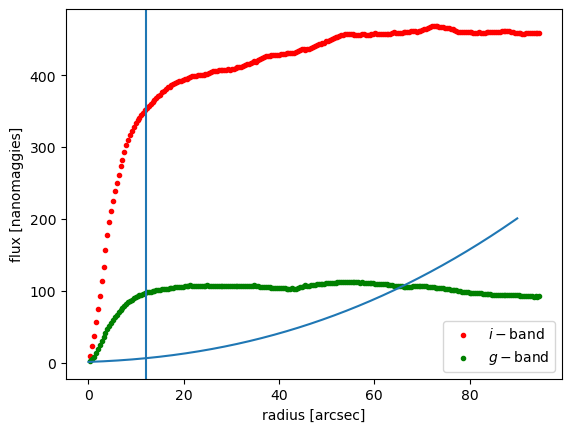

In [55]:
plt.scatter(icog['rbins']*icog['pixscale'], icog['fbins'], marker='.', label='$i-$band', color='r')
plt.scatter(gcog['rbins']*gcog['pixscale'], gcog['fbins'], marker='.', label='$g-$band', color='g')
plt.plot(rs, SGA_cog(rs, 1, 1, 1, 1, 1))
plt.legend()
plt.axvline(2*NSA['ELPETRO_THETA_R'][40094])
plt.xlabel('radius [arcsec]')
plt.ylabel('flux [nanomaggies]')

Text(0, 0.5, 'flux [nanomaggies]')

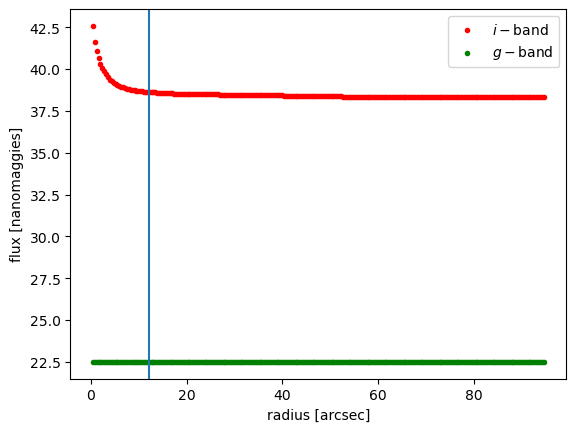

In [75]:
plt.scatter(icog['rbins']*icog['pixscale'], pogson_mag_from_flux(icog['fbins']*10**-9), marker='.', label='$i-$band', color='r')
plt.scatter(gcog['rbins']*gcog['pixscale'], pogson_mag_from_flux(gcog['fbins']**10**-9), marker='.', label='$g-$band', color='g')
plt.legend()
plt.axvline(2*NSA['ELPETRO_THETA_R'][40094])
plt.xlabel('radius [arcsec]')
plt.ylabel('flux [nanomaggies]')

### try converting to pogson magnitude and then fitting curve of growth

In [228]:
def SGA_cog_mag(r, mtot, m0, a1, a2):

    m = mtot + m0 * np.log(1 + a1*(r/10)**(-a2))

    return m


In [229]:
res = curve_fit(SGA_cog_mag, np.array(icog['rbins']*icog['pixscale'])[0], 
          np.array(pogson_mag_from_flux(icog['fbins']))[0])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_52858/2054671628.py:3: RuntimeWarning: invalid value encountered in log
  m = mtot + m0 * np.log(1 + a1*(r/10)**(-a2))


In [230]:
i_mag_model = SGA_cog_mag(rs, res[0][0], res[0][1], res[0][2], res[0][3])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_52858/2054671628.py:3: RuntimeWarning: divide by zero encountered in power
  m = mtot + m0 * np.log(1 + a1*(r/10)**(-a2))


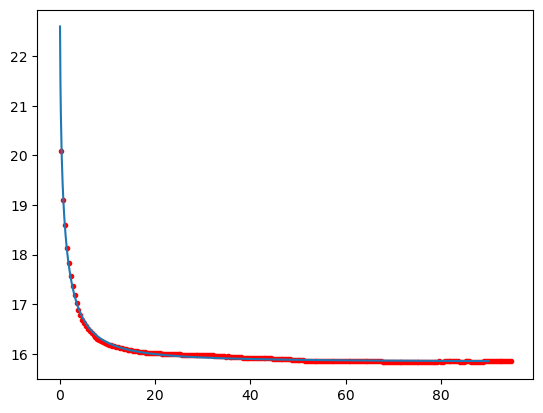

In [231]:
plt.scatter(icog['rbins']*icog['pixscale'], pogson_mag_from_flux(icog['fbins']), marker='.', label='$i-$band', color='r')
plt.plot(rs, i_mag_model)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_52858/2054671628.py:3: RuntimeWarning: divide by zero encountered in power
  m = mtot + m0 * np.log(1 + a1*(r/10)**(-a2))


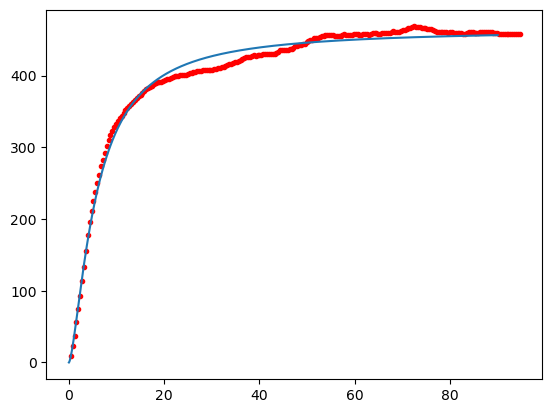

In [152]:
plt.scatter(icog['rbins']*icog['pixscale'], icog['fbins'], marker='.', label='$i-$band', color='r')
plt.plot(rs, 10**((SGA_cog_mag(rs, res[0][0], res[0][1], res[0][2], res[0][3]) - 22.5)/-2.5))

In [153]:
res2 = curve_fit(SGA_cog_mag, np.array(gcog['rbins']*gcog['pixscale'])[0], 
          np.array(pogson_mag_from_flux(gcog['fbins']))[0])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_52858/2054671628.py:3: RuntimeWarning: invalid value encountered in log
  m = mtot + m0 * np.log(1 + a1*(r/10)**(-a2))


In [154]:
g_mag_model = SGA_cog_mag(rs, res2[0][0], res2[0][1], res2[0][2], res2[0][3])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_52858/2054671628.py:3: RuntimeWarning: divide by zero encountered in power
  m = mtot + m0 * np.log(1 + a1*(r/10)**(-a2))


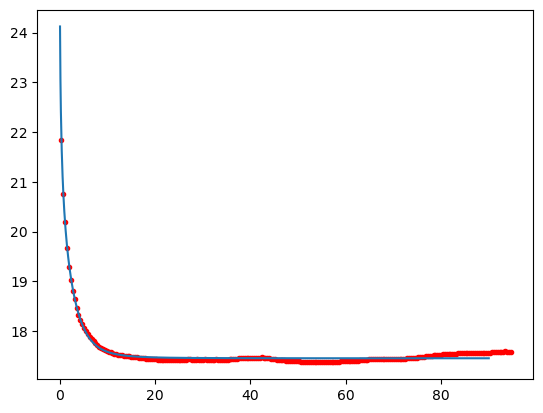

In [156]:
plt.scatter(gcog['rbins']*gcog['pixscale'], pogson_mag_from_flux(gcog['fbins']), marker='.', label='$g-$band', color='r')
plt.plot(rs, g_mag_model)
# plt.ylim(38,42)

Text(0.5, 1.0, 'iauname curve of growth')

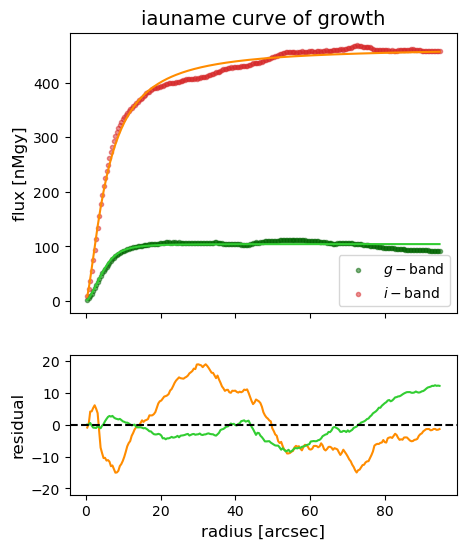

In [223]:
# plot with residual

fig, ax = plt.subplots(2,1, height_ratios = (2,1), figsize=(5,6), sharex=True)

ax[0].scatter(gcog['rbins']*gcog['pixscale'], gcog['fbins'], marker='.', label='$g-$band', color='darkgreen',alpha=0.5)
ax[0].scatter(icog['rbins']*icog['pixscale'], icog['fbins'], marker='.', label='$i-$band', color='tab:red', alpha=0.5)
ax[0].plot(np.array(gcog['rbins']*gcog['pixscale'])[0],
           10**((SGA_cog_mag(np.array(gcog['rbins']*gcog['pixscale'])[0], res2[0][0], res2[0][1], res2[0][2], res2[0][3]) - 22.5)/-2.5), 
           color='limegreen')
ax[0].plot(np.array(icog['rbins']*icog['pixscale'])[0], 
           10**((SGA_cog_mag(np.array(icog['rbins']*icog['pixscale'])[0], res[0][0], res[0][1], res[0][2], res[0][3]) - 22.5)/-2.5), 
           color='darkorange')

i_res = 10**((SGA_cog_mag(np.array(icog['rbins']*icog['pixscale'])[0], res[0][0], res[0][1], res[0][2], res[0][3]) - 22.5)/-2.5) - np.array(icog['fbins'])[0]
g_res = 10**((SGA_cog_mag(np.array(gcog['rbins']*gcog['pixscale'])[0], res2[0][0], res2[0][1], res2[0][2], res2[0][3]) - 22.5)/-2.5) - np.array(gcog['fbins'])[0]

ax[1].plot(np.array(icog['rbins']*icog['pixscale'])[0], i_res, color='darkorange')
ax[1].plot(np.array(gcog['rbins']*gcog['pixscale'])[0], g_res, color='limegreen')

ax[1].axhline(0, linestyle='--', color='k')

y_ext = np.max([np.max(np.abs(i_res)), np.max(np.abs(g_res))])

ax[1].set_ylim(-y_ext-3, y_ext+3)

ax[0].legend()

ax[1].set_xlabel('radius [arcsec]', fontsize=12)
ax[1].set_ylabel('residual', fontsize=12)
ax[0].set_ylabel('flux [nMgy]', fontsize=12)

ax[0].set_title('iauname' + ' curve of growth', fontsize=14)



success! --> profit?

### extract fluxes within 0.5 Rpet disk and 0.5 Rpet - Rpet annulus

In [158]:
Rpet = NSA['ELPETRO_THETA'][40094]
Rpet

6.0252204

In [159]:
i_in_mag = SGA_cog_mag(0.5*Rpet, res[0][0], res[0][1], res[0][2], res[0][3])
i_rpet_mag = SGA_cog_mag(Rpet, res[0][0], res[0][1], res[0][2], res[0][3])

g_in_mag = SGA_cog_mag(0.5*Rpet, res2[0][0], res2[0][1], res2[0][2], res2[0][3])
g_rpet_mag = SGA_cog_mag(Rpet, res2[0][0], res2[0][1], res2[0][2], res2[0][3])

In [167]:
(g_rpet_mag - 2*g_in_mag) - (i_rpet_mag - 2*i_in_mag)

-1.6686882341736258

In [168]:
g_rpet_mag - g_in_mag

-0.8347072122845951

In [169]:
pogson_mag_from_flux(g_out_flux)

18.567042953884048

In [160]:
i_in_mag

17.2173257900946

In [161]:
i_rpet_mag

16.543103663363542

In [162]:
# convert back to flux

i_in_flux = 10**((22.5 - i_in_mag)/2.5)
i_rpet_flux = 10**((22.5 - i_rpet_mag)/2.5) 


g_in_flux = 10**((22.5 - g_in_mag)/2.5)
g_rpet_flux = 10**((22.5 - g_rpet_mag)/2.5) 

In [163]:
i_out_flux = i_rpet_flux - i_in_flux
g_out_flux = g_rpet_flux - g_in_flux

In [170]:
g_out_flux

37.42681051571596

In [164]:
i_out_flux

111.67308004546979

In [171]:
cd = -2.5*np.log10(g_out_flux/g_in_flux) + 2.5 * np.log10(i_out_flux/i_in_flux)

In [172]:
cd

-0.321288958382408

In [112]:
# DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/'
# NSA_FN = DATA_FOLDER + 'nsa_v1_0_1.fits'
KIAS_FN = '/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits'

In [113]:
KIAS = Table.read(KIAS_FN)

In [115]:
KIAS[KIAS['IAUNAME'] == 'J030526.94+005144.9']

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J030526.94+005144.9,03h/p00/J030526.94+005144.9,46.3623017248186,0.8624933853392395,40553,-1,-1,-1,84316,-1,25.114393,0.11779706,sdss,0.036948916,7675,1,178,301,394.4018,786.3415,40094,0.11809768,3.2845166 .. 1195.74,6.0204563 .. 0.00085950183,1,2.950474 .. 1139.7069,-16.864342 .. -23.157263,55.096455 .. 1042.4894,0.6361384 .. 0.113492,0.14524387 .. 0.035253428,9.116431e-06 .. 1.1590381e-12,0.0007365413 .. 1.1454777,4.1634325e-06,0.051471043,0.023352249,127307250000.0,125.22980499267578,145.50259399414062,8 .. 11,0.016057538 .. 0.0,10595.301 .. 0.0,-0.077921234 .. -0.12675858,0.0069088247 .. -0.036795978,0.85489714

In [232]:
new_cols = ['g_mtot', 'g_m0', 'g_a1', 'g_a2', 
            'i_mtot', 'i_m0', 'i_a1', 'i_a2',
            'NSA_cd']


for col in new_cols:

    NSA[col] = np.ones(len(NSA))*np.nan

In [234]:
NSA[40094]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J010027.92+155325.8,01h/p14/J010027.92+155325.8,15.11640661936367,15.89049027194408,43173,-1,-1,-1,-1,-1,17.770514,0.12134381,sdss,0.03508221,1904,6,248,301,625.645,338.9165,42714,0.122084945,0.0 .. 342.75214,0.0 .. 0.009598245,1,0.23133434 .. 360.87137,-13.901886 .. -21.875736,0.0 .. 956.5407,0.53014886 .. 0.09458265,-0.0143809635 .. 0.03262118,6.1708285e-08 .. 5.046998e-17,0.0038706507 .. 1.2899282,4.0889275e-12,0.0020115222,0.021532292,48644840000.0,87.21723937988281,89.3848876953125,0 .. 10,0.0 .. 0.0,0.0 .. 0.0,0.0 .. -0.06886988,0.0 .. 0.14382605,0.0 .. 0.7249339,0.0 .. 57.793518,0.0 .. 298.49878,0.0 .. 0.013235596,0.0 .. 114.336044,0.0 .. 0.4745724,0.80020946,147.65503,0.84807384,152.73825,0.0 .. 325.9471,1.53519 .. 0.07629392,6.0,0.7471683,149.4462,0.0 .. 0.040838137,0.0 .. -0.045952246,3 .. 0,0,11,v2_1_14,0.22341923 .. 258.39,5.593759,2.2243848,5.9274197,1.6647049,421,408,51821,15.11637427988228,15.89050293434482,0.0,sdss,legacy,good,215,15.116369,15.890514,0.84807384,152.73825,151.91687,0.018247942,6.0252204,2.3323617,6.4421487,6.0252204,0.0 .. 306.6938,0.0 .. 0.0133958785,-9999.0 .. 2.2035263,-9999.0 .. 6.2497745,0.9974852,1.0812311 .. 0.9996417,-10024.209 .. 1.0000665,0.0 .. 322.50616,0.0 .. 0.006174561,1,0.28274304 .. 325.503,-14.795866 .. -21.827778,0.0 .. 544.7954,0.6617222 .. 0.05076708,5.8108662e-06 .. 8.861459e-09,38139048000.0,0.0013320607 .. 1.1026502,0.000107461645,0.102130294,0.025691947,1.0,nan,nan,nan,nan,nan,nan,nan,nan,nan


In [237]:
iauname = NSA['IAUNAME'][40094]
iauname

'J010027.92+155325.8'

In [239]:
fn = DATA_FOLDER + '/' + iauname +  + '-8-' + 'i' + '-cog.fits'

TypeError: bad operand type for unary +: 'str'